<a href="https://colab.research.google.com/github/azrasm/ml-hotel-booking-analysis/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import HalvingGridSearchCV
import pickle

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MU Projekat/hotel_ociscen.csv')

In [ ]:
df = df.drop(columns=["reservation_status", "reservation_status_date", "country"])

In [ ]:
#labela i feature
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

In [ ]:
y.value_counts(normalize=True)

,proportion
is_canceled,
0,0.595594
1,0.404406


In [ ]:
numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = X.select_dtypes(include=["object"]).columns

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])

In [ ]:
#train+temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

#validation+test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", y_train.shape)
print("Validation:", y_val.shape)
print("Test:", y_test.shape)

Train: (83573,)
Validation: (17908,)
Test: (17909,)


In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", knn)
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Konfuzijska matrica:
 [[8346 2320]
 [2971 4272]]


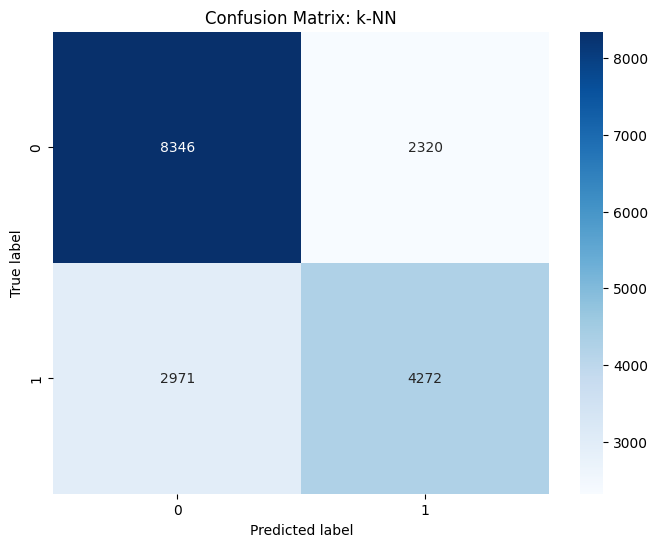

In [ ]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Konfuzijska matrica:\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: k-NN")
plt.show()

In [ ]:
#Klasifikacijski izvještaj
print("Izvještaj o klasifikaciji:\n", classification_report(y_test, y_pred))

#Tačnost i Kappa statistika
accuracy = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
print("Tačnost:", accuracy)
print("Kappa statistika:", kappa)

Izvještaj o klasifikaciji:
               precision    recall  f1-score   support

           0       0.74      0.78      0.76     10666
           1       0.65      0.59      0.62      7243

    accuracy                           0.70     17909
   macro avg       0.69      0.69      0.69     17909
weighted avg       0.70      0.70      0.70     17909

Tačnost: 0.7045619520911274
Kappa statistika: 0.37774525406121673


In [ ]:
#Multi-class Precision, Recall, F1
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

print("Preciznost za svaku klasu:", precision)
print("Recall za svaku klasu:", recall)
print("F1-score za svaku klasu:", f1)

Preciznost za svaku klasu: [0.7374746  0.64805825]
Recall za svaku klasu: [0.78248641 0.58981085]
F1-score za svaku klasu: [0.75931402 0.61756415]


In [ ]:
#Specificity
cm = confusion_matrix(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)
sensitivity = TP / (TP + FN)

print("Specificity:", specificity)

Specificity: 0.7824864054003375


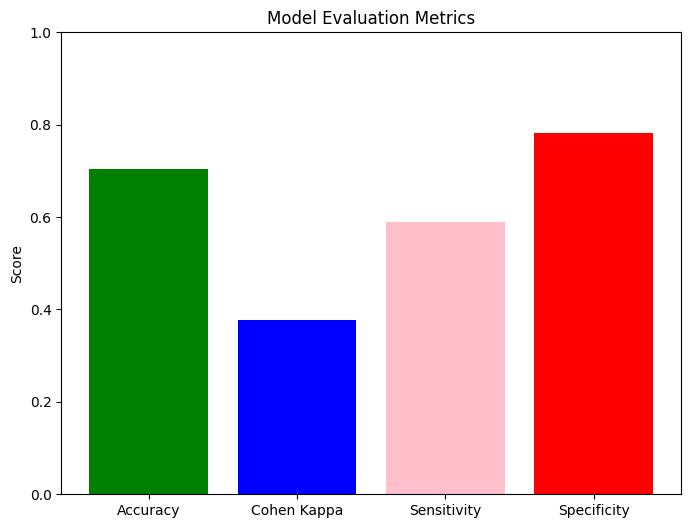

In [ ]:
#Vizualizacija tačnosti, Kappa statistike, Sensitivity i Specificity
metrics = {
    'Accuracy': accuracy,
    'Cohen Kappa': kappa,
    'Sensitivity': sensitivity,
    'Specificity': specificity
}
plt.figure(figsize=(8, 6))
plt.bar(metrics.keys(), metrics.values(), color=['green', 'blue', 'pink', 'red'])
plt.title('Model Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()

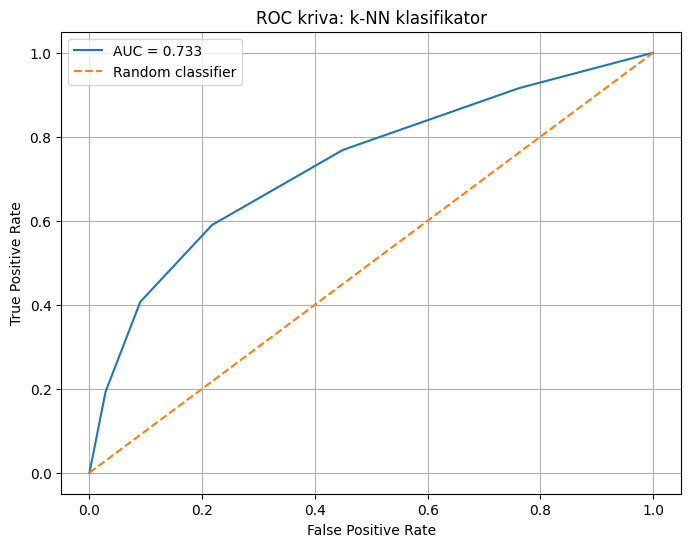

In [ ]:
#ROC kriva
y_proba = model.predict_proba(X_test)[:, 1]

y_true = y_test.values.ravel()

fpr, tpr, thresholds = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC kriva: k-NN klasifikator")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Unakrsna validacija
cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1-score po foldovima:", cv_scores)
print("Prosjek:", cv_scores.mean())

F1-score po foldovima: [0.61525476 0.61047907 0.61091304 0.61909161 0.62131414]
Prosjek: 0.6154105216097384


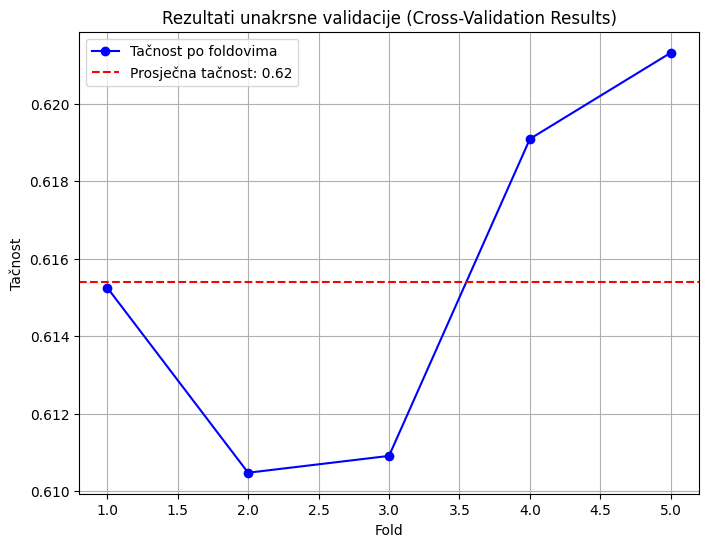

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', color='b', label='Tačnost po foldovima')
plt.axhline(np.mean(cv_scores), color='r', linestyle='--', label=f'Prosječna tačnost: {np.mean(cv_scores):.2f}')
plt.title('Rezultati unakrsne validacije (Cross-Validation Results)')
plt.xlabel('Fold')
plt.ylabel('Tačnost')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Uticaj nebalansiranosti i Oversampling
smote_pipeline = ImbPipeline(steps=[
    ("preprocessing", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", KNeighborsClassifier(n_neighbors=8))
])

smote_pipeline.fit(X_train, y_train)
y_pred_smote = smote_pipeline.predict(X_test)

print("Izvještaj (SMOTE):\n")
print(classification_report(y_test, y_pred_smote))

Izvještaj (SMOTE):

              precision    recall  f1-score   support

           0       0.75      0.74      0.75     10666
           1       0.63      0.63      0.63      7243

    accuracy                           0.70     17909
   macro avg       0.69      0.69      0.69     17909
weighted avg       0.70      0.70      0.70     17909



In [ ]:
#Undersampling
under_pipeline = ImbPipeline(steps=[
    ("preprocessing", preprocessor),
    ("undersample", RandomUnderSampler(random_state=42)),
    ("classifier", KNeighborsClassifier(n_neighbors=8))
])

under_pipeline.fit(X_train, y_train)
y_pred_under = under_pipeline.predict(X_test)

print("Izvještaj (Undersampling):\n")
print(classification_report(y_test, y_pred_under))

Izvještaj (Undersampling):

              precision    recall  f1-score   support

           0       0.74      0.77      0.75     10666
           1       0.64      0.60      0.62      7243

    accuracy                           0.70     17909
   macro avg       0.69      0.68      0.68     17909
weighted avg       0.70      0.70      0.70     17909



In [ ]:
#Tuning parametara sa HalvingGridSearchCV
knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', KNeighborsClassifier())
])

param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['minkowski', 'cityblock'],
    'classifier__p': [1, 2]
}

halving_search = HalvingGridSearchCV(
    knn_pipeline,
    param_grid,
    factor=2,
    cv=5,
    scoring='f1',
    verbose=2,
    n_jobs=-1
)

halving_search.fit(X_train, y_train)

print("Najbolji parametri:", halving_search.best_params_)
print("Najbolji F1-score:", halving_search.best_score_)

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 2611
max_resources_: 83573
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 32
n_resources: 2611
Fitting 5 folds for each of 32 candidates, totalling 160 fits
----------
iter: 1
n_candidates: 16
n_resources: 5222
Fitting 5 folds for each of 16 candidates, totalling 80 fits
----------
iter: 2
n_candidates: 8
n_resources: 10444
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 3
n_candidates: 4
n_resources: 20888
Fitting 5 folds for each of 4 candidates, totalling 20 fits
----------
iter: 4
n_candidates: 2
n_resources: 41776
Fitting 5 folds for each of 2 candidates, totalling 10 fits
----------
iter: 5
n_candidates: 1
n_resources: 83552
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Najbolji parametri: {'classifier__metric': 'cityblock', 'classifier__n_neighbors': 9, 'classifier__p': 2, 'classifier__weights': 'uniform'}
Najbolji F1-score: 0.6202

In [ ]:
#Evaluacija na test skupu
best_knn = halving_search.best_estimator_

y_pred_best = best_knn.predict(X_test)

print("Izvještaj najboljeg modela:\n")
print(classification_report(y_test, y_pred_best))

print("Tačnost najboljeg modela:", accuracy_score(y_test, y_pred_best))

Izvještaj najboljeg modela:

              precision    recall  f1-score   support

           0       0.74      0.80      0.77     10666
           1       0.67      0.58      0.62      7243

    accuracy                           0.71     17909
   macro avg       0.70      0.69      0.70     17909
weighted avg       0.71      0.71      0.71     17909

Tačnost najboljeg modela: 0.7146686023786922


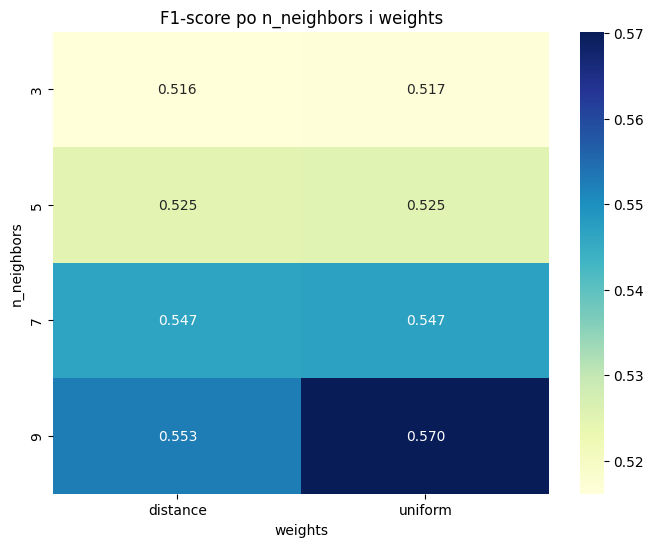

In [ ]:
results = pd.DataFrame(halving_search.cv_results_)

results = results[['param_classifier__n_neighbors',
                   'param_classifier__weights',
                   'param_classifier__metric',
                   'mean_test_score']]

pivot_table = results.pivot_table(
    values='mean_test_score',
    index='param_classifier__n_neighbors',
    columns='param_classifier__weights'
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap='YlGnBu')
plt.title("F1-score po n_neighbors i weights")
plt.ylabel("n_neighbors")
plt.xlabel("weights")
plt.show()

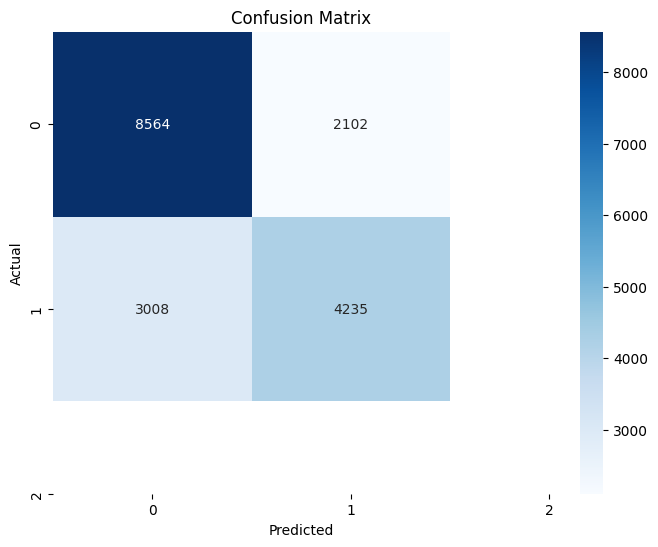

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', KNeighborsClassifier(
        weights='uniform',
        algorithm='ball_tree',
        metric='cityblock',
        n_neighbors=4
    ))
])

#Treniranje
knn_pipeline.fit(X_train, y_train)

#Predikcija
prediction1 = knn_pipeline.predict(X_test)

print("Tačnost modela:", accuracy_score(y_test, prediction1))

Tačnost modela: 0.7078005472108996


In [ ]:
import joblib

model_path = '/content/drive/MyDrive/MU Projekat/knn_pipeline.pkl'
joblib.dump(knn_pipeline, model_path)

['/content/drive/MyDrive/MU Projekat/knn_pipeline.pkl']

In [ ]:
knn_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', KNeighborsClassifier(
        weights='distance',
        algorithm='ball_tree',
        n_neighbors=4
    ))
])

#Treniranje
knn_pipeline.fit(X_train, y_train)

#Predikcija
prediction1 = knn_pipeline.predict(X_test)

print("Tačnost modela:", accuracy_score(y_test, prediction1))

Tačnost modela: 0.6888156792674075


In [ ]:
knn_best = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', KNeighborsClassifier(
        weights='uniform',
        algorithm='ball_tree',
        metric='cityblock',
        n_neighbors=9
    ))
])

#Treniranje
knn_best.fit(X_train, y_train)

#Predikcija
prediction = knn_best.predict(X_test)

print("Tačnost modela:", accuracy_score(y_test, prediction))

Tačnost modela: 0.7143894131442292


In [ ]:
import joblib

model_path = '/content/drive/MyDrive/MU Projekat/knn_best.pkl'
joblib.dump(knn_best, model_path)

['/content/drive/MyDrive/MU Projekat/knn_best.pkl']